# Class 11 — Frequentist vs. Bayesian Duality
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

---

This notebook builds intuition for the **frequentist–Bayesian duality** — two coherent but philosophically different ways to interpret probability.  
We simulate the classic thought experiments from the slides and visualize how priors, likelihoods, and posteriors interact.

**Contents:**
1. [Setup & Imports](#1)
2. [Statistical Concepts: Frequentist vs. Bayesian](#2)
3. [The Sun Exploded — A Tale of Two Statisticians](#3)
4. [Pascal & Fermat's Interrupted Game](#4)
5. [Bayesian Updating — Coin Flips](#5)
6. [Sensitivity to the Prior](#6)
7. [Key Takeaways](#7)

---

<a id='1'></a>
## 1. Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import beta as beta_dist
from math import comb

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
GRAY   = '#6B7280'
GOLD   = '#D97706'
PURPLE = '#7C3AED'

print('Libraries loaded. Ready.')

Libraries loaded. Ready.


<a id='2'></a>
## 2. Statistical Concepts: Frequentist vs. Bayesian

The same formula can have two interpretations. The key question is: **what does the probability condition on?**

- **Frequentist** quantities condition on a hypothesis ($H_0$ or $H_A$) and average over hypothetical repeated experiments.
- **Bayesian** quantities condition on the observed data and describe beliefs about hypotheses.

The critical divide:
$$\underbrace{P(Z > z \mid H_0)}_\text{p-value (frequentist)} \quad \neq \quad \underbrace{P(H_0 \mid Z > z)}_\text{FDR (Bayesian)}$$

In [3]:
concepts = pd.DataFrame([
    {'Concept': 'P-value',                'Definition': 'P(Z > z | H₀)',        'Interpretation': 'Frequentist'},
    {'Concept': 'Confidence level',       'Definition': 'P(CI(X) ∋ θ)',         'Interpretation': 'Frequentist'},
    {'Concept': 'Bias',                   'Definition': 'E[θ̂] − θ',            'Interpretation': 'Frequentist'},
    {'Concept': 'Standard error',         'Definition': 'sqrt(Var(θ̂))',         'Interpretation': 'Frequentist'},
    {'Concept': 'Sensitivity (power)',    'Definition': 'P(Z > z | H_A)',       'Interpretation': 'Frequentist'},
    {'Concept': 'Specificity',            'Definition': '1 − P(Z > z | H₀)',    'Interpretation': 'Frequentist'},
    {'Concept': 'Positive Pred. Value',  'Definition': 'P(H_A | Z > z)',        'Interpretation': 'Bayesian'},
    {'Concept': 'False Discovery Rate',  'Definition': 'P(H₀ | Z > z)',         'Interpretation': 'Bayesian'},
])

# Colour-coded display
def colour_row(row):
    colour = '#dbeafe' if row['Interpretation'] == 'Frequentist' else '#fef9c3'
    return [f'background-color: {colour}'] * len(row)

concepts.style.apply(colour_row, axis=1).set_caption(
    'Blue = Frequentist (conditions on hypothesis) · Yellow = Bayesian (conditions on data)'
)

,Concept,Definition,Interpretation
0,P-value,P(Z > z | H₀),Frequentist
1,Confidence level,P(CI(X) ∋ θ),Frequentist
2,Bias,E[θ̂] − θ,Frequentist
3,Standard error,sqrt(Var(θ̂)),Frequentist
4,Sensitivity (power),P(Z > z | H_A),Frequentist
5,Specificity,1 − P(Z > z | H₀),Frequentist
6,Positive Pred. Value,P(H_A | Z > z),Bayesian
7,False Discovery Rate,P(H₀ | Z > z),Bayesian


<a id='3'></a>
## 3. The Sun Exploded — A Tale of Two Statisticians

**Setup (from xkcd):** A neutrino detector tests whether the sun has gone nova.  
After detecting, it rolls two dice: if both show 6 it lies, otherwise it tells the truth.  
The detector says **YES**.

The frequentist and the Bayesian reach opposite conclusions. Let's compute both exactly.

In [4]:
# --- Frequentist analysis ---
# Under H0 (sun intact), what is P(detector says YES)?
p_lie   = 1/36          # prob detector lies (both dice = 6)
p_truth = 1 - p_lie    # prob detector tells truth

# If sun is intact (H0), detector says YES only if it lies
p_yes_given_H0 = p_lie
print('=== Frequentist ===')
print(f'P(detector says YES | H0) = 1/36 = {p_yes_given_H0:.4f}')
print(f'p-value = {p_yes_given_H0:.4f}  < 0.05  →  Reject H0. Conclusion: sun has exploded.\n')

# --- Bayesian analysis ---
# Need: P(sun exploded | detector says YES)
# Prior: the sun almost certainly has NOT exploded
prior_exploded = 1e-6     # P(H_A): vanishingly small
prior_intact   = 1 - prior_exploded

# Likelihoods
p_yes_given_HA = p_truth  # If sun exploded, detector tells truth → says YES

# Bayes' theorem
numerator   = p_yes_given_HA * prior_exploded
denominator = p_yes_given_HA * prior_exploded + p_yes_given_H0 * prior_intact
posterior_exploded = numerator / denominator

print('=== Bayesian ===')
print(f'Prior P(sun exploded) = {prior_exploded:.2e}')
print(f'P(YES | sun exploded) = {p_yes_given_HA:.4f}  (detector tells truth)')
print(f'P(YES | sun intact)   = {p_yes_given_H0:.4f}  (detector lies)')
print(f'\nPosterior P(sun exploded | YES) = {posterior_exploded:.6f}')
print(f'→ Probability sun has NOT exploded ≈ {1 - posterior_exploded:.6f}')
print(f'Conclusion: almost certainly the sun is fine.')

=== Frequentist ===
P(detector says YES | H0) = 1/36 = 0.0278
p-value = 0.0278  < 0.05  →  Reject H0. Conclusion: sun has exploded.

=== Bayesian ===
Prior P(sun exploded) = 1.00e-06
P(YES | sun exploded) = 0.9722  (detector tells truth)
P(YES | sun intact)   = 0.0278  (detector lies)

Posterior P(sun exploded | YES) = 0.000035
→ Probability sun has NOT exploded ≈ 0.999965
Conclusion: almost certainly the sun is fine.


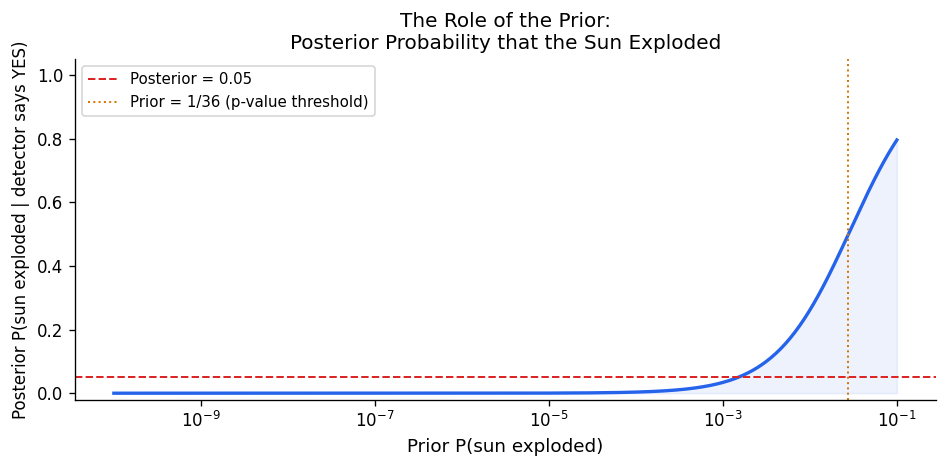


For the posterior to exceed 0.5, you need a prior P(H_A) > 0.0288
That is roughly 1-in-35 odds the sun explodes — still tiny, but far from 1-in-a-million.


In [5]:
# Visualize how the posterior changes as the prior on solar explosion varies
priors = np.logspace(-10, -1, 500)   # from 10^-10 to 0.1

def posterior_ha(prior_ha):
    num = p_yes_given_HA * prior_ha
    den = p_yes_given_HA * prior_ha + p_yes_given_H0 * (1 - prior_ha)
    return num / den

posts = posterior_ha(priors)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(priors, posts, color=BLUE, lw=2)
ax.axhline(0.05, color=RED, ls='--', lw=1.2, label='Posterior = 0.05')
ax.axvline(1/36, color=GOLD, ls=':', lw=1.2, label='Prior = 1/36 (p-value threshold)')
ax.fill_between(priors, posts, alpha=0.08, color=BLUE)
ax.set_xlabel('Prior P(sun exploded)', fontsize=11)
ax.set_ylabel('Posterior P(sun exploded | detector says YES)', fontsize=10)
ax.set_title('The Role of the Prior:\nPosterior Probability that the Sun Exploded', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

# Find the prior needed for posterior > 0.5
crossover = priors[np.searchsorted(posts, 0.5)]
print(f'\nFor the posterior to exceed 0.5, you need a prior P(H_A) > {crossover:.4f}')
print(f'That is roughly 1-in-{1/crossover:.0f} odds the sun explodes — still tiny, but far from 1-in-a-million.')

**Takeaway:** The p-value ($1/36 \approx 0.028$) is the same regardless of how plausible solar explosion is. The Bayesian posterior correctly shrinks toward zero when the prior is tiny. The frequentist rejects $H_0$ by ignoring prior information; the Bayesian does not.

<a id='4'></a>
## 4. Pascal & Fermat's Interrupted Game

Two players flip a fair coin. First to 10 wins takes the \$1 pot.  
If the game is **interrupted**, each player should receive their expected winnings from the current state.

Pascal and Fermat solved this in 1654 — it's the birth of the frequentist view of probability.

In [7]:
from math import comb

def prob_heads_wins(heads_so_far, tails_so_far, target=10):
    """
    Probability that 'heads' wins from the current state.
    Heads needs (target - heads_so_far) more wins.
    Tails needs (target - tails_so_far) more wins.
    """
    h_needed = target - heads_so_far
    t_needed = target - tails_so_far

    if h_needed <= 0:
        return 1.0
    if t_needed <= 0:
        return 0.0

    # In the remaining (h_needed + t_needed - 1) flips,
    # heads wins if it gets >= h_needed heads.
    max_flips = h_needed + t_needed - 1
    p = sum(
        comb(max_flips, k) * (0.5 ** max_flips)
        for k in range(h_needed, max_flips + 1)
    )
    return p

# Three scenarios from the slides
scenarios = [
    ('Equal (5H, 5T)',  5, 5),
    ('9H vs 8T',       9, 8),
    ('9H vs 7T',       9, 7),
]

print(f"{'Scenario':<20}  {'P(heads wins)':>15}  {'Share to Heads':>15}  {'Share to Tails':>15}")
print('-' * 70)
for name, h, t in scenarios:
    p = prob_heads_wins(h, t)
    print(f'{name:<20}  {p:>15.4f}  ${p:>13.4f}  ${1 - p:>13.4f}')

Scenario                P(heads wins)   Share to Heads   Share to Tails
----------------------------------------------------------------------
Equal (5H, 5T)                 0.5000  $       0.5000  $       0.5000
9H vs 8T                       0.7500  $       0.7500  $       0.2500
9H vs 7T                       0.8750  $       0.8750  $       0.1250


In [8]:
# Simulate many full games starting from 9H vs 8T and verify P ≈ analytical value
N_SIM = 100_000

def simulate_from_state(h, t, target=10, n_sims=N_SIM):
    heads_wins = 0
    for _ in range(n_sims):
        hh, tt = h, t
        while hh < target and tt < target:
            if np.random.rand() < 0.5:
                hh += 1
            else:
                tt += 1
        if hh >= target:
            heads_wins += 1
    return heads_wins / n_sims

for name, h, t in scenarios:
    analytic = prob_heads_wins(h, t)
    simulated = simulate_from_state(h, t)
    print(f'{name:<20}  analytic={analytic:.4f}  simulated={simulated:.4f}  diff={abs(analytic - simulated):.4f}')

Equal (5H, 5T)        analytic=0.5000  simulated=0.5003  diff=0.0003
9H vs 8T              analytic=0.7500  simulated=0.7471  diff=0.0029
9H vs 7T              analytic=0.8750  simulated=0.8751  diff=0.0001


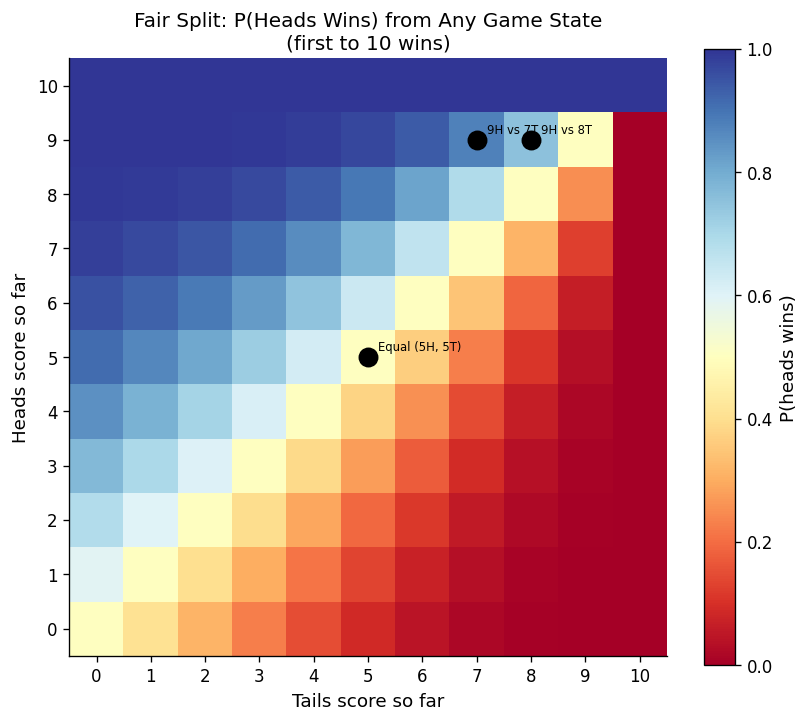


The diagonal (equal scores) gives P = 0.5 — split evenly.
Near the top-right corner (both near 10), small advantages become decisive.


In [9]:
# Heat map: P(heads wins) for all (heads_score, tails_score) combinations
target = 10
grid = np.zeros((target + 1, target + 1))
for h in range(target + 1):
    for t in range(target + 1):
        grid[h, t] = prob_heads_wins(h, t, target)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(grid, origin='lower', cmap='RdYlBu', vmin=0, vmax=1, aspect='equal')
plt.colorbar(im, ax=ax, label='P(heads wins)')

# Mark the three slide scenarios
for name, h, t in scenarios:
    ax.scatter(t, h, s=120, color='black', zorder=5)
    ax.annotate(name, (t, h), textcoords='offset points', xytext=(6, 4), fontsize=7)

ax.set_xlabel('Tails score so far', fontsize=11)
ax.set_ylabel('Heads score so far', fontsize=11)
ax.set_title(f'Fair Split: P(Heads Wins) from Any Game State\n(first to {target} wins)', fontsize=12)
ax.set_xticks(range(target + 1))
ax.set_yticks(range(target + 1))
plt.tight_layout()
plt.show()

print('\nThe diagonal (equal scores) gives P = 0.5 — split evenly.')
print('Near the top-right corner (both near 10), small advantages become decisive.')

<a id='5'></a>
## 5. Bayesian Updating — Coin Flips

A Bayesian starts with a **prior belief** about a coin's bias $\theta = P(\text{heads})$.  
After each flip, the prior is updated to a **posterior** using Bayes' theorem:

$$P(\theta \mid \text{data}) \propto P(\text{data} \mid \theta) \cdot P(\theta)$$

For a coin flip with a Beta prior this has a clean closed form:  
if $\theta \sim \text{Beta}(\alpha, \beta)$ and we observe $h$ heads and $t$ tails, then:

$$\theta \mid h, t \sim \text{Beta}(\alpha + h,\ \beta + t)$$

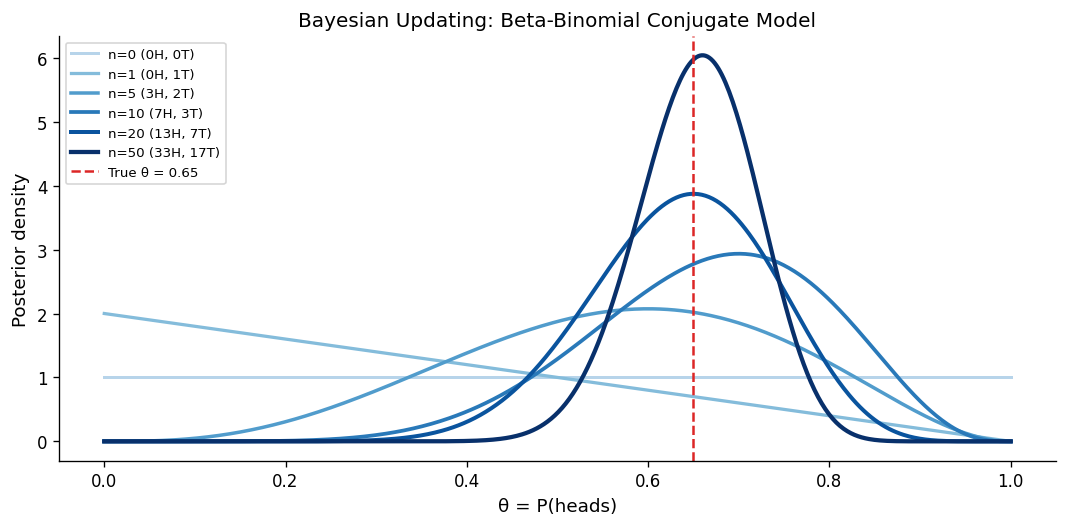

True theta = 0.65
After 50 flips: posterior mean = 0.654


In [10]:
# True coin bias (unknown to the Bayesian agent)
TRUE_THETA = 0.65

# Simulate flips
N_FLIPS = 50
flips = (np.random.rand(N_FLIPS) < TRUE_THETA).astype(int)  # 1=heads, 0=tails

# Prior: Beta(1, 1) = uniform over [0, 1] — no prior knowledge
alpha0, beta0 = 1, 1

theta_grid = np.linspace(0, 1, 500)

# Snapshots after 0, 1, 5, 10, 20, 50 flips
snapshots = [0, 1, 5, 10, 20, 50]
colours = plt.cm.Blues(np.linspace(0.3, 1.0, len(snapshots)))

fig, ax = plt.subplots(figsize=(9, 4.5))

for i, (n, col) in enumerate(zip(snapshots, colours)):
    h = flips[:n].sum()
    t = n - h
    alpha_n = alpha0 + h
    beta_n  = beta0  + t
    pdf = beta_dist.pdf(theta_grid, alpha_n, beta_n)
    label = f'n={n} ({h}H, {t}T)'
    ax.plot(theta_grid, pdf, color=col, lw=1.8 + i * 0.15, label=label)

ax.axvline(TRUE_THETA, color=RED, ls='--', lw=1.5, label=f'True θ = {TRUE_THETA}')
ax.set_xlabel('θ = P(heads)', fontsize=11)
ax.set_ylabel('Posterior density', fontsize=11)
ax.set_title('Bayesian Updating: Beta-Binomial Conjugate Model', fontsize=12)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

print(f'True theta = {TRUE_THETA}')
print(f'After {N_FLIPS} flips: posterior mean = {(alpha0 + flips.sum()) / (alpha0 + beta0 + N_FLIPS):.3f}')

In [11]:
# Credible interval (Bayesian) vs. Confidence interval (frequentist)
from scipy.stats import binom

n_obs   = N_FLIPS
h_obs   = flips.sum()
theta_hat = h_obs / n_obs   # frequentist MLE

alpha_n = alpha0 + h_obs
beta_n  = beta0  + (n_obs - h_obs)

# Bayesian 95% credible interval
ci_low_b,  ci_high_b  = beta_dist.ppf([0.025, 0.975], alpha_n, beta_n)

# Frequentist 95% confidence interval (normal approximation)
se = np.sqrt(theta_hat * (1 - theta_hat) / n_obs)
ci_low_f,  ci_high_f  = theta_hat - 1.96 * se, theta_hat + 1.96 * se

print('After {:d} flips ({:d} heads, {:d} tails):'.format(n_obs, int(h_obs), n_obs - int(h_obs)))
print(f'\n  Frequentist MLE:           θ̂ = {theta_hat:.3f}')
print(f'  Frequentist 95% CI:        [{ci_low_f:.3f}, {ci_high_f:.3f}]')
print(f'  Interpretation: If we repeat this experiment many times, 95% of such intervals contain the true θ.')
print()
print(f'  Bayesian posterior mean:   θ̂ = {alpha_n / (alpha_n + beta_n):.3f}')
print(f'  Bayesian 95% credible int: [{ci_low_b:.3f}, {ci_high_b:.3f}]')
print(f'  Interpretation: Given the data, there is a 95% probability that θ lies in this interval.')
print()
print(f'  True θ = {TRUE_THETA}   (inside both intervals: {ci_low_f:.3f} < {TRUE_THETA} < {ci_high_f:.3f})')

After 50 flips (33 heads, 17 tails):

  Frequentist MLE:           θ̂ = 0.660
  Frequentist 95% CI:        [0.529, 0.791]
  Interpretation: If we repeat this experiment many times, 95% of such intervals contain the true θ.

  Bayesian posterior mean:   θ̂ = 0.654
  Bayesian 95% credible int: [0.521, 0.776]
  Interpretation: Given the data, there is a 95% probability that θ lies in this interval.

  True θ = 0.65   (inside both intervals: 0.529 < 0.65 < 0.791)


<a id='6'></a>
## 6. Sensitivity to the Prior

A key criticism of Bayesianism is that results depend on the prior. Let's see how much.

We test whether a coin is fair ($\theta = 0.5$) or biased ($\theta > 0.5$), using three priors:
- **Flat prior**: Beta(1, 1) — no prior knowledge
- **Skeptical prior**: Beta(10, 10) — strong belief in fairness
- **Informative prior**: Beta(2, 8) — prior belief the coin favours tails

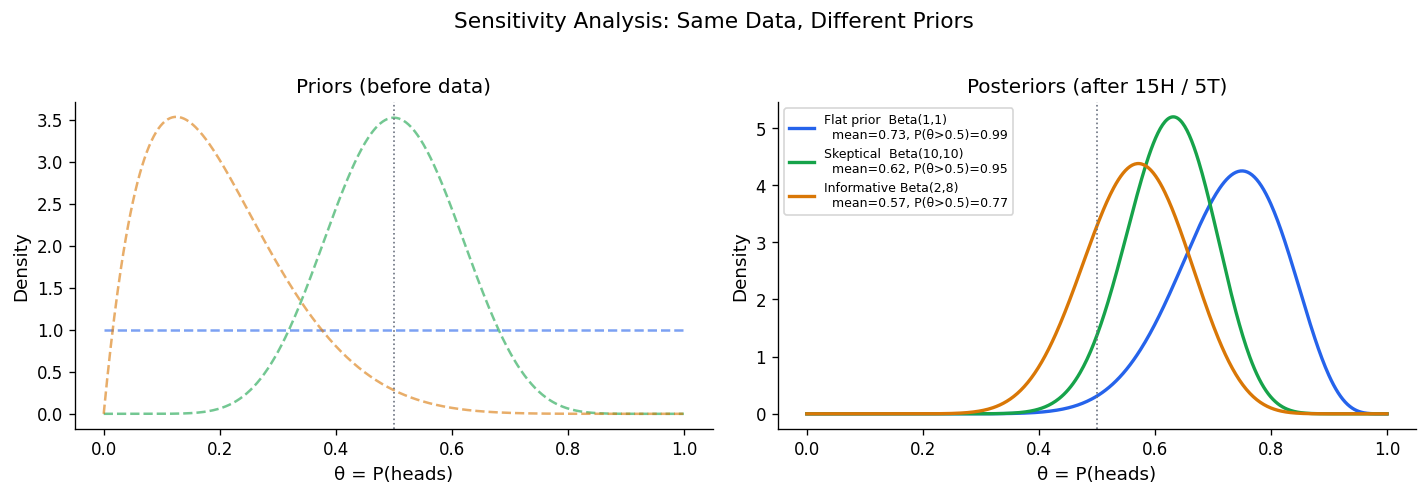


Obs: 15 heads in 20 flips (θ_hat = 0.75)
The skeptical prior pulls the posterior toward 0.5 more aggressively.
With enough data, all priors converge to the same posterior (Bernstein–von Mises).


In [12]:
# Data: 15 heads in 20 flips (biased towards heads)
h_data, n_data = 15, 20
t_data = n_data - h_data

priors_params = [
    ('Flat prior  Beta(1,1)',         1,  1,  BLUE),
    ('Skeptical  Beta(10,10)',        10, 10, GREEN),
    ('Informative Beta(2,8)',          2,  8, GOLD),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

theta_grid = np.linspace(0, 1, 500)
for label, a0, b0, col in priors_params:
    a_post = a0 + h_data
    b_post = b0 + t_data

    prior_pdf = beta_dist.pdf(theta_grid, a0, b0)
    post_pdf  = beta_dist.pdf(theta_grid, a_post, b_post)
    post_mean = a_post / (a_post + b_post)
    prob_gt_half = 1 - beta_dist.cdf(0.5, a_post, b_post)

    axes[0].plot(theta_grid, prior_pdf, color=col, ls='--', lw=1.5, alpha=0.6)
    axes[1].plot(theta_grid, post_pdf,  color=col, lw=2,
                 label=f'{label}\n  mean={post_mean:.2f}, P(θ>0.5)={prob_gt_half:.2f}')

for ax, title in zip(axes, ['Priors (before data)', f'Posteriors (after {h_data}H / {t_data}T)']):
    ax.axvline(0.5, color=GRAY, ls=':', lw=1)
    ax.set_xlabel('θ = P(heads)')
    ax.set_ylabel('Density')
    ax.set_title(title, fontsize=12)

axes[1].legend(fontsize=7.5, loc='upper left')
plt.suptitle('Sensitivity Analysis: Same Data, Different Priors', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nObs: 15 heads in 20 flips (θ_hat = 0.75)')
print('The skeptical prior pulls the posterior toward 0.5 more aggressively.')
print('With enough data, all priors converge to the same posterior (Bernstein–von Mises).')

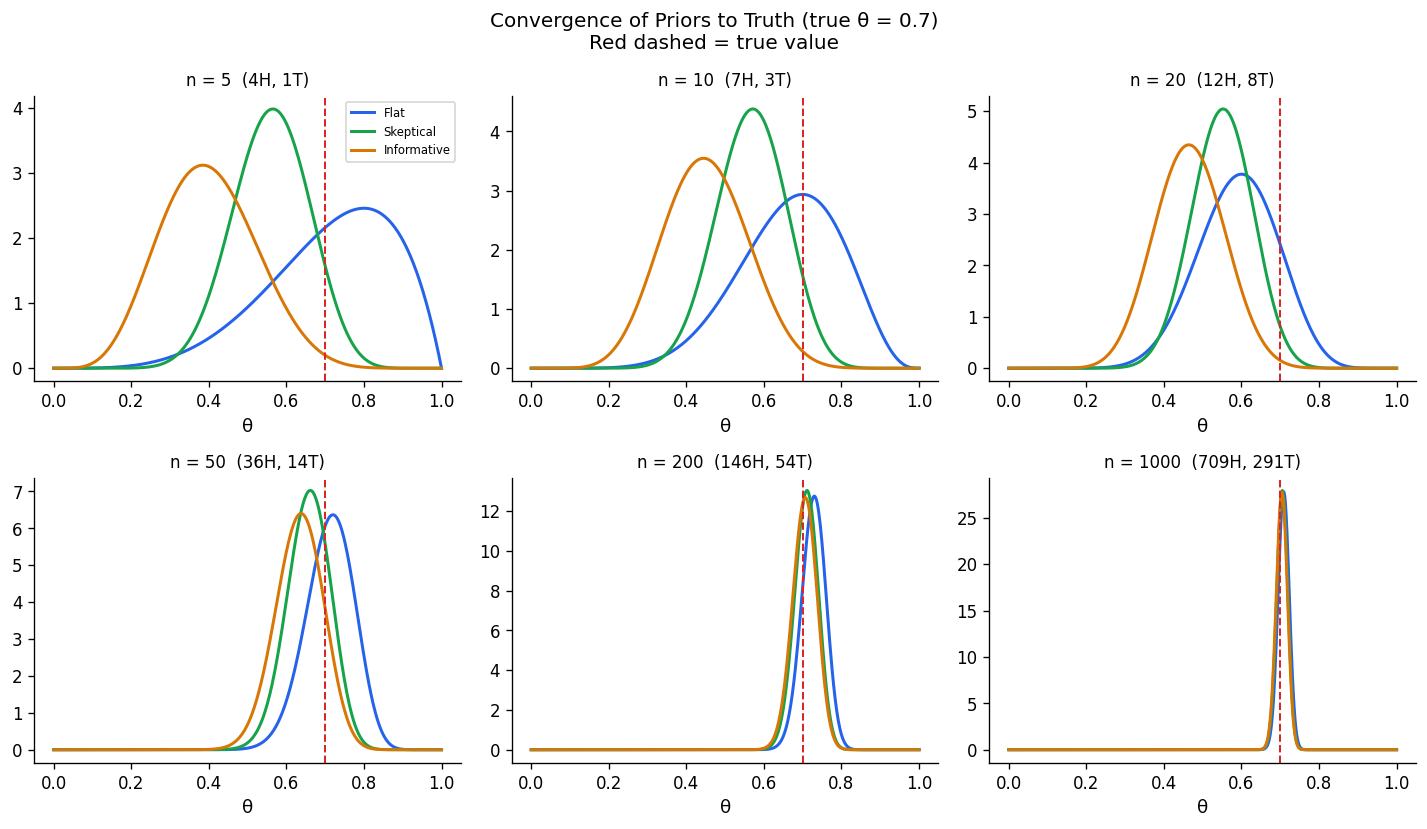

As n grows, all posteriors converge to the same answer — the data overwhelms the prior.


In [13]:
# Show convergence: as N grows, prior choice matters less
n_values = [5, 10, 20, 50, 200, 1000]
true_theta = 0.70

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=False)
axes = axes.flatten()

np.random.seed(0)
flips_large = (np.random.rand(max(n_values)) < true_theta).astype(int)

for ax, n in zip(axes, n_values):
    h = flips_large[:n].sum()
    t = n - h
    for label, a0, b0, col in priors_params:
        post_pdf = beta_dist.pdf(theta_grid, a0 + h, b0 + t)
        ax.plot(theta_grid, post_pdf, color=col, lw=1.8, label=label.split()[0])
    ax.axvline(true_theta, color=RED, ls='--', lw=1.2)
    ax.set_title(f'n = {n}  ({h}H, {t}T)', fontsize=10)
    ax.set_xlabel('θ')
    if ax == axes[0]:
        ax.legend(fontsize=7)

plt.suptitle(f'Convergence of Priors to Truth (true θ = {true_theta})\nRed dashed = true value', fontsize=12)
plt.tight_layout()
plt.show()

print('As n grows, all posteriors converge to the same answer — the data overwhelms the prior.')

<a id='7'></a>
## 7. Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **Frequentist probability** | Long-run frequency of a repeatable event. Objective but requires repeated trials. |
| **Bayesian probability** | Rational degree of belief. Subjective (prior-dependent) but handles one-off events. |
| **Both obey Kolmogorov** | Same rules, different interpretations — like mass vs. weight |
| **P-value ≠ P(H₀ is true)** | The frequentist p-value conditions on H₀; the posterior conditions on the data |
| **Sun exploded example** | A small p-value can be misleading when the prior on H_A is tiny |
| **Pascal–Fermat (1654)** | Frequentist splitting: give each player their expected winnings |
| **Leibniz (1657)** | Bayesian view: probability as a calculus of opinions updated by evidence |
| **Bayesian updating** | Prior × Likelihood ∝ Posterior; posterior becomes next prior |
| **Prior sensitivity** | Different priors → different posteriors, but they converge as data grows |
| **Credible vs. confidence** | Credible interval: θ is inside with 95% probability. CI: procedure covers 95% of time. |

---

## 📚 References

- Hacking, I. (1975). *The Emergence of Probability.* Cambridge University Press.
- Jaynes, E.T. (2003). *Probability Theory: The Logic of Science.* Cambridge University Press.
- Efron, B. (2013). *A 250-year argument: Belief, behavior, and the bootstrap.* Bull. AMS, 50(1).
- Wasserstein, R.L. & Lazar, N.A. (2016). *The ASA statement on p-values.* The American Statistician, 70(2).

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*